In [12]:
from pathlib import Path
import gzip
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from stable_platform_matchings.domain.instance import Instance
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

In [13]:
sns.set_theme(context="paper", style="ticks")

In [14]:
root = Path("../results/exp_6")
all_jsons = list(root.rglob("*.json.gz"))
graph_data_filename = "../data/graph_0-14960_00_new.pickle"
instance = Instance.from_yaml(Path('../data/anon_14_day_instances/2020-08-27.yaml'))

In [15]:
LC_TO_USD = instance.lc_to_usd
TRUCK_FIXED_COST = instance.truck_fixed_cost

MAX_DEVIATION_POTENTIAL = 12

DEV_POT_BINS = np.linspace(2, 12, 7)
COST_BINS = np.linspace(65, 110, 7)

ZERO_TOL = 1e-8

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

def pp_formatter(x, pos):
    return f"{x * 100:.0f}pp"

In [16]:
data = []

for file in all_jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        aggregate_payload = json.load(f)

    job_id = aggregate_payload["job_id"]

    for payload in aggregate_payload["runs"]:
        n_hist_sets = payload["metadata"]["n_hist_sets"]

        instance_snapshot = payload["summary_naive"]["instance_snapshot"]
        instance_id = instance_snapshot["instance_id"]

        het_costs = payload["sampled_inputs"]["het_costs"]
        intermediaries = instance_snapshot["intermediaries"]


        total_quantity = sum(
            farmer["quantity"] for farmer in instance_snapshot["farmers"]
        )

        total_fruit_value = total_quantity * instance.fruit_price_per_ton

        naive_result = payload["summary_naive"]["platform_solve_result"]
        primary_naive_result = naive_result["primary_result"]
        naive_platform_profit = primary_naive_result["platform_profit"]

        scaled_root_result = payload["summary_scaled_root"]["platform_solve_result"]
        primary_scaled_root_result = scaled_root_result["primary_result"]
        scaled_root_platform_profit = primary_scaled_root_result["platform_profit"]

        scaled_result = payload["summary_scaled"]["platform_solve_result"]
        primary_scaled_result = scaled_result["primary_result"]
        scaled_platform_profit = primary_scaled_result["platform_profit"]

        row = {
            "job_id": job_id,
            "n_hist_sets": n_hist_sets,
            "naive_platform_profit_pct": naive_platform_profit / total_fruit_value,
            "scaled_root_platform_profit_pct": scaled_root_platform_profit / total_fruit_value,
            "scaled_platform_profit_pct": scaled_platform_profit / total_fruit_value,
        }

        data.append(row)

df = pd.DataFrame(data)

In [17]:
df["naive_scaled_root_diff"] =  df["naive_platform_profit_pct"] - df["scaled_root_platform_profit_pct"]
df["naive_scaled_diff"] = df["naive_platform_profit_pct"] - df["scaled_platform_profit_pct"]
df["scaled_root_scaled_diff"] = df["scaled_root_platform_profit_pct"] - df["scaled_platform_profit_pct"]

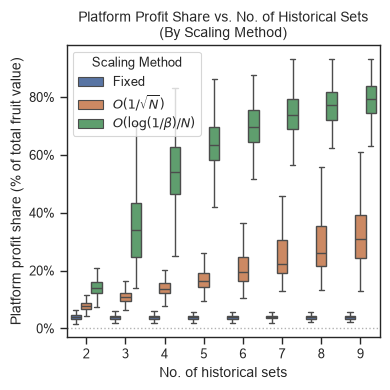

In [18]:
plt.figure(figsize=(4, 4))

melted = df.melt(
    id_vars = "n_hist_sets",
    value_vars = ["naive_platform_profit_pct", "scaled_root_platform_profit_pct", "scaled_platform_profit_pct"],
    var_name  = "method",
    value_name = "platform_profit"
)

sns.boxplot(
    melted.query("n_hist_sets >= 2"),
    x="n_hist_sets",
    y="platform_profit",
    hue="method",
    showfliers=False,
    palette="deep"
)
plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()

ax.legend(title="Scaling Method", handles=handles, labels=[r"Fixed", r"$O(1/\sqrt{N})$", r"$O(\log (1 / \beta) / N)$"])
ax.set_ylabel("Platform profit share (% of total fruit value)")
ax.set_xlabel("No. of historical sets")
ax.set_title(
    r"Platform Profit Share vs. No. of Historical Sets"
    "\n(By Scaling Method)"
)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

plt.tight_layout()
plt.savefig("../figures/exp_6/platform_profit_pct_by_scaling_method.png", bbox_inches='tight', dpi=300)
plt.show()

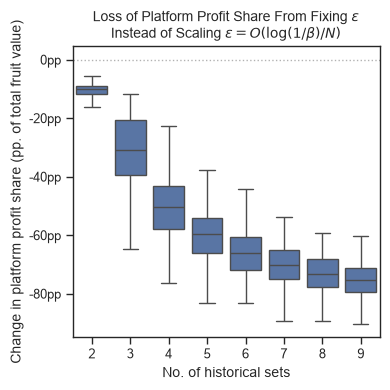

In [19]:
plt.figure(figsize=(4, 4))

sns.boxplot(
    df.query("n_hist_sets >= 2"),
    x="n_hist_sets",
    y="naive_scaled_diff",
    showfliers=False,
)
plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()

ax.set_ylabel("Change in platform profit share (pp. of total fruit value)")
ax.set_xlabel("No. of historical sets")
ax.set_title(
    r"Loss of Platform Profit Share From Fixing $\epsilon$" "\nInstead of Scaling "r"$\epsilon = O(\log(1/\beta)/N)$"
)
ax.yaxis.set_major_formatter(FuncFormatter(pp_formatter))

plt.tight_layout()
plt.savefig("../figures/exp_6/loss_naive_scale.png", bbox_inches='tight', dpi=300)
plt.show()

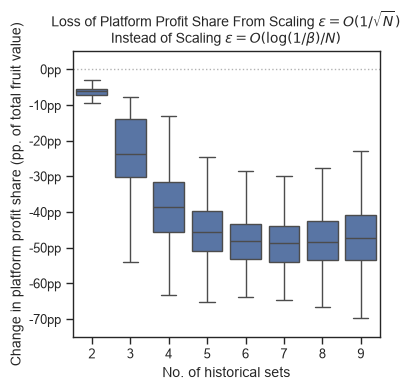

In [21]:
plt.figure(figsize=(4, 4))

sns.boxplot(
    df.query("n_hist_sets >= 2"),
    x="n_hist_sets",
    y="scaled_root_scaled_diff",
    showfliers=False,
)
plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()

ax.set_ylabel("Change in platform profit share (pp. of total fruit value)")
ax.set_xlabel("No. of historical sets")
ax.set_title(
    r"Loss of Platform Profit Share From Scaling $\epsilon = O(1/\sqrt{N})$"
    "\nInstead of Scaling "r"$\epsilon = O(\log(1/\beta)/N)$"
)
ax.set_ylim(-0.75, 0.05)
ax.yaxis.set_major_formatter(FuncFormatter(pp_formatter))

plt.tight_layout()
plt.savefig("../figures/exp_6/loss_scale_root_scale.png", bbox_inches='tight', dpi=300)
plt.show()